In [1]:
df_football = df_football.rename(columns={
    'home_team': 'HomeTeam',
    'away_team': 'AwayTeam',
    'Country': 'Country'
})

df_merged = pd.merge(df_matches, df_football, on=['HomeTeam', 'AwayTeam'], how='inner')

print(f"Successfully merged data! Total matches in dataset: {df_merged.shape[0]}")
print(df_merged[['MatchDate', 'HomeTeam', 'AwayTeam', 'FTHome', 'FTAway', 'Ball_Possession_Home']].head())

NameError: name 'df_football' is not defined

In [2]:
import pandas as pd

df_elo = pd.read_csv("EloRatings.csv")
df_football = pd.read_csv("Football.csv")
df_matches = pd.read_csv("Matches.csv")

df_football = df_football.rename(columns={
    'home_team': 'HomeTeam',
    'away_team': 'AwayTeam',
    'Country': 'Country'
})

df_merged = pd.merge(df_matches, df_football, on=['HomeTeam', 'AwayTeam'], how='inner')

print(f"Successfully merged data! Total matches in dataset: {df_merged.shape[0]}")
print(df_merged[['MatchDate', 'HomeTeam', 'AwayTeam', 'FTHome', 'FTAway', 'Ball_Possession_Home']].head())

C:\Users\Shlok Chaudhari\AppData\Local\Temp\ipykernel_10660\3681584004.py:5: DtypeWarning: Columns (0: home_score, 1: away_score, 2: home_team_goals_current_time, 3: home_team_goals_current_score, 4: home_team_goals, 5: home_team_goals_assist, 6: away_team_goals_current_time, 7: away_team_goals_current_score, 8: away_team_goals, 9: away_team_goals_assist, 10: home_team_yellow_card_current_time, 11: home_team_yellow_card, 12: home_team_yellow_card_why, 13: away_team_yellow_card_current_time, 14: away_team_yellow_card, 15: away_team_yellow_card_why, 16: home_team_red_card_current_time, 17: home_team_red_card, 18: home_team_red_card_why, 19: away_team_red_card_current_time, 20: away_team_red_card, 21: away_team_red_card_why, 22: home_team_substitutions_current_time, 23: home_team_substitutions, 24: home_team_substitutions_with, 25: home_team_substitution_why, 26: away_team_substitutions_current_time, 27: away_team_substitutions, 28: away_team_substitutions_with, 29: away_team_substitution

Successfully merged data! Total matches in dataset: 548969
    MatchDate   HomeTeam AwayTeam  FTHome  FTAway Ball_Possession_Home
0  2000-07-28  Marseille   Troyes     3.0     1.0                  72%
1  2000-07-28  Marseille   Troyes     3.0     1.0                  56%
2  2000-07-28  Marseille   Troyes     3.0     1.0                  62%
3  2000-07-28  Marseille   Troyes     3.0     1.0                  55%
4  2000-07-28  Marseille   Troyes     3.0     1.0                  NaN


In [3]:
df_matches['MatchDate'] = pd.to_datetime(df_matches['MatchDate'])
df_football['MatchDate'] = pd.to_datetime(df_football['Date_day'])

df_cleaned_merge = pd.merge(df_matches, df_football, on=['HomeTeam', 'AwayTeam', 'MatchDate'], how='inner')

print(f"Cleaned Merged Total matches: {df_cleaned_merge.shape[0]}")
print(df_cleaned_merge[['MatchDate', 'HomeTeam', 'AwayTeam', 'FTHome', 'FTAway', 'Ball_Possession_Home']].head())

Cleaned Merged Total matches: 0
Empty DataFrame
Columns: [MatchDate, HomeTeam, AwayTeam, FTHome, FTAway, Ball_Possession_Home]
Index: []


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.5 MB 19.1 MB/s eta 0:00:01
   ---------------- ----------------------- 3.9/9.5 MB 15.7 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.5 MB 9.6 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.5 MB 8.3 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 7.7 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.5 MB 6.3 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.5 MB 5.6 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 5.2 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 4.5 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.5 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 4.0 MB/s eta 0:00:01
   ------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


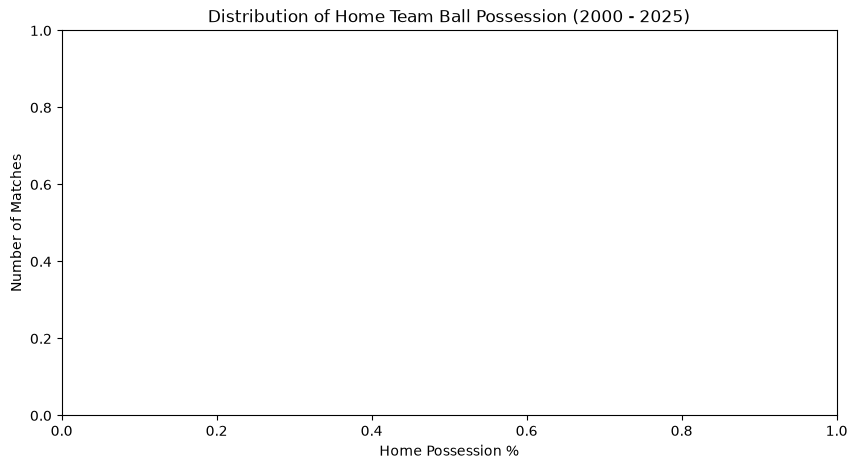

In [4]:
!pip install matplotlib seaborn

import matplotlib.pyplot as plt
import seaborn as sns

if df_cleaned_merge['Ball_Possession_Home'].dtype == 'object':
    df_cleaned_merge['Ball_Possession_Home'] = df_cleaned_merge['Ball_Possession_Home'].str.rstrip('%').astype('float')

plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned_merge['Ball_Possession_Home'], kde=True, color='blue', bins=30)
plt.title('Distribution of Home Team Ball Possession (2000 - 2025)')
plt.xlabel('Home Possession %')
plt.ylabel('Number of Matches')
plt.show()

In [5]:
avg_home_goals = df_cleaned_merge['FTHome'].mean()
avg_away_goals = df_cleaned_merge['FTAway'].mean()
avg_home_possession = df_cleaned_merge['Ball_Possession_Home'].mean()

print("=== GLOBAL FOOTBALL INSIGHTS (2000-2025) ===")
print(f"Average Goals Scored by Home Teams: {avg_home_goals:.2f}")
print(f"Average Goals Scored by Away Teams: {avg_away_goals:.2f}")
print(f"Average Home Team Possession: {avg_home_possession:.2f}%")

TypeError: Cannot perform reduction 'mean' with string dtype

In [6]:
df_cleaned_merge['Ball_Possession_Home'] = df_cleaned_merge['Ball_Possession_Home'].astype(str).str.rstrip('%')
df_cleaned_merge['Ball_Possession_Home'] = pd.to_numeric(df_cleaned_merge['Ball_Possession_Home'], errors='coerce').fillna(0)

df_cleaned_merge['FTHome'] = pd.to_numeric(df_cleaned_merge['FTHome'], errors='coerce')
df_cleaned_merge['FTAway'] = pd.to_numeric(df_cleaned_merge['FTAway'], errors='coerce')

avg_home_goals = df_cleaned_merge['FTHome'].mean()
avg_away_goals = df_cleaned_merge['FTAway'].mean()
avg_home_possession = df_cleaned_merge['Ball_Possession_Home'].mean()

print("=== GLOBAL FOOTBALL INSIGHTS (2000-2025) ===")
print(f"Average Goals Scored by Home Teams: {avg_home_goals:.2f}")
print(f"Average Goals Scored by Away Teams: {avg_away_goals:.2f}")
print(f"Average Home Team Possession: {avg_home_possession:.2f}%")

=== GLOBAL FOOTBALL INSIGHTS (2000-2025) ===
Average Goals Scored by Home Teams: nan
Average Goals Scored by Away Teams: nan
Average Home Team Possession: nan%


In [7]:
print(f"Number of rows in dataset: {df_cleaned_merge.shape[0]}")

print("\n=== Matches Preview ===")
print(df_matches[['MatchDate', 'HomeTeam', 'AwayTeam']].head(2))

print("\n=== Football Stats Preview ===")
print(df_football.iloc[:, :4].head(2))

Number of rows in dataset: 0

=== Matches Preview ===
   MatchDate   HomeTeam    AwayTeam
0 2000-07-28  Marseille      Troyes
1 2000-07-28   Paris SG  Strasbourg

=== Football Stats Preview ===
   Country      League            HomeTeam       AwayTeam
0  Germany  Bundesliga  B. Monchengladbach  Werder Bremen
1  Germany  Bundesliga            Freiburg          Mainz


In [8]:
df_final = df_merged.copy()

df_final = df_final.drop_duplicates(subset=['MatchDate', 'HomeTeam', 'AwayTeam'])

df_final['Ball_Possession_Home'] = df_final['Ball_Possession_Home'].astype(str).str.rstrip('%')
df_final['Ball_Possession_Home'] = pd.to_numeric(df_final['Ball_Possession_Home'], errors='coerce')
df_final['FTHome'] = pd.to_numeric(df_final['FTHome'], errors='coerce')
df_final['FTAway'] = pd.to_numeric(df_final['FTAway'], errors='coerce')

df_final = df_final.dropna(subset=['FTHome', 'FTAway', 'Ball_Possession_Home'])

print(f"=== RE-CLEANED DATASET ===")
print(f"Total Matches Analyzed: {df_final.shape[0]}")
print(f"Average Goals Scored by Home Teams: {df_final['FTHome'].mean():.2f}")
print(f"Average Goals Scored by Away Teams: {df_final['FTAway'].mean():.2f}")
print(f"Average Home Team Possession: {df_final['Ball_Possession_Home'].mean():.2f}%")

=== RE-CLEANED DATASET ===
Total Matches Analyzed: 50262
Average Goals Scored by Home Teams: 1.47
Average Goals Scored by Away Teams: 1.13
Average Home Team Possession: 51.02%


C:\Users\Shlok Chaudhari\AppData\Local\Temp\ipykernel_10660\2594876379.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=averages, palette=['#1f77b4', '#ff7f0e'])


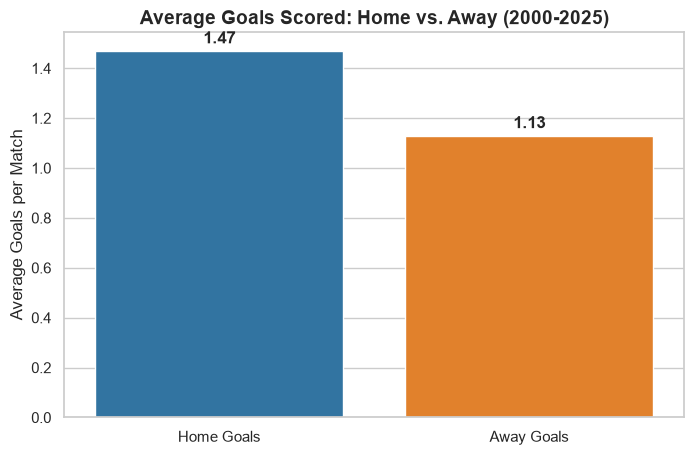

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

categories = ['Home Goals', 'Away Goals']
averages = [1.47, 1.13]

plt.figure(figsize=(8, 5))
sns.barplot(x=categories, y=averages, palette=['#1f77b4', '#ff7f0e'])

plt.title('Average Goals Scored: Home vs. Away (2000-2025)', fontsize=14, fontweight='bold')
plt.ylabel('Average Goals per Match', fontsize=12)

for i, v in enumerate(averages):
    plt.text(i, v + 0.03, str(v), ha='center', fontweight='bold')

plt.show()

In [ ]:
df_final['Home_Shooting_Accuracy'] = (df_final['HomeTarget'] / df_final['HomeShots']) * 100

def possession_bracket(pos):
    if pos < 45: return 'Low Possession (<45%)'
    elif pos <= 55: return 'Medium Possession (45-55%)'
    else: return 'High Possession (>55%)'

df_final['Possession_Bracket'] = df_final['Ball_Possession_Home'].apply(possession_bracket)

accuracy_results = df_final.groupby('Possession_Bracket')['Home_Shooting_Accuracy'].mean()
print(accuracy_results)

C:\Users\Shlok Chaudhari\AppData\Local\Temp\ipykernel_10660\3460958934.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Possession_Bracket', y='Home_Shooting_Accuracy', data=df_final,


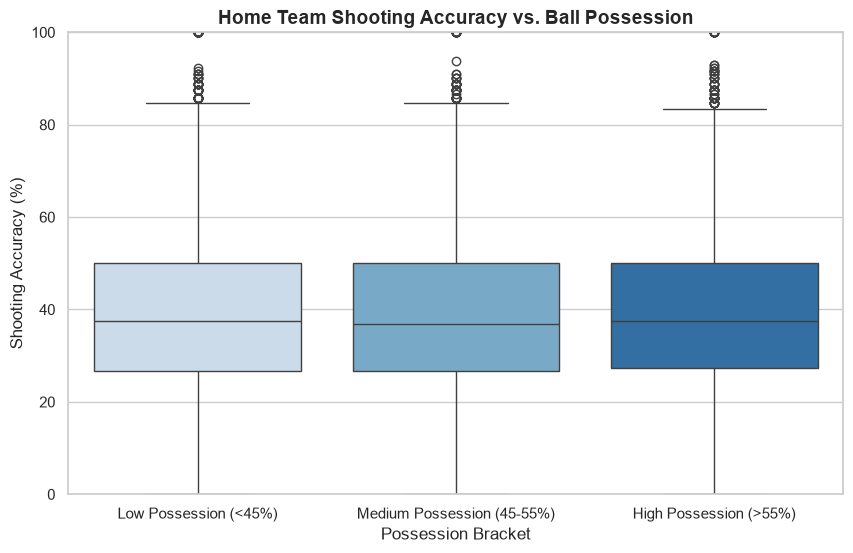

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Possession_Bracket', y='Home_Shooting_Accuracy', data=df_final, 
            order=['Low Possession (<45%)', 'Medium Possession (45-55%)', 'High Possession (>55%)'],
            palette='Blues')

plt.title('Home Team Shooting Accuracy vs. Ball Possession', fontsize=14, fontweight='bold')
plt.xlabel('Possession Bracket', fontsize=12)
plt.ylabel('Shooting Accuracy (%)', fontsize=12)
plt.ylim(0, 100)

plt.show()